# 0.0 — Análise Exploratória do Dataset de Deepfake

Objetivo: auditar o dataset antes de qualquer treinamento, procurando problemas que possam gerar **data leakage, atalhos espúrios, label noise, baixa qualidade facial ou viés de fonte**.

Estrutura esperada:

```text
synthetic-face-detection/
└── training/
    ├── dataset/
    │   ├── fake/
    │   └── real/
    ├── notebooks/
    │   └── 0.0_analise_exploratoria.ipynb
    └── scripts/
        └── face_detector.py
```

Composição informada:

### Fake
- StyleGAN2: 2.000
- StyleGAN3: 2.000
- Stable Diffusion 1.4: 2.000
- Stable Diffusion 2.1: 2.000

### Real
- FFHQ: 6.000
- CelebA-HQ: 2.000

> **Risco metodológico importante:** como os dados reais e sintéticos vêm de fontes completamente diferentes, `classe` e `fonte` estão fortemente confundidas. Uma CNN pode aprender características do dataset de origem (compressão, resolução, pipeline, cor, fundo, etc.) em vez de aprender sinais de deepfake. Esta EDA procura justamente esses atalhos.

In [44]:
import os
import sys
import random
import hashlib
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from PIL import Image, ImageFile

import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.datasets import ImageFolder
from tqdm.notebook import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = False

SEMENTE_GLOBAL = 42
random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

## 1. Localização robusta do projeto

O notebook pode ser iniciado pelo VS Code/Jupyter com diretórios de trabalho diferentes. Em vez de assumir `Path("dataset")`, esta célula procura automaticamente a pasta `training/` que contém `dataset/` e `scripts/`.

In [45]:
def encontrar_training_dir():
    cwd = Path.cwd().resolve()
    candidatos = [cwd, *cwd.parents]

    for base in candidatos:
        # Caso já estejamos dentro de training/
        if (base / "dataset").is_dir() and (base / "scripts").is_dir():
            return base

        # Caso estejamos na raiz do projeto ou acima dela
        training = base / "training"
        if (training / "dataset").is_dir() and (training / "scripts").is_dir():
            return training

    raise FileNotFoundError(
        "Não foi possível localizar training/dataset e training/scripts "
        f"a partir de {cwd}"
    )


TRAINING_DIR = encontrar_training_dir()
PROJECT_DIR = TRAINING_DIR.parent
CAMINHO_DATASET = TRAINING_DIR / "dataset"
CAMINHO_ANALISE = TRAINING_DIR / "analysis"

CAMINHO_ANALISE.mkdir(parents=True, exist_ok=True)

if str(TRAINING_DIR) not in sys.path:
    sys.path.insert(0, str(TRAINING_DIR))

from scripts.face_detector import FaceDetector

print("PROJECT_DIR :", PROJECT_DIR)
print("TRAINING_DIR:", TRAINING_DIR)
print("DATASET     :", CAMINHO_DATASET)
print("ANALYSIS    :", CAMINHO_ANALISE)
print("Dataset existe:", CAMINHO_DATASET.exists())

PROJECT_DIR : /home/guilhermemathiasreis/Documents/synthetic-face-detection
TRAINING_DIR: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training
DATASET     : /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset
ANALYSIS    : /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/analysis
Dataset existe: True


## 2. Composição esperada

Como o dataset está organizado apenas em `fake/` e `real/`, o notebook consegue validar os totais por classe, mas **não consegue atribuir cada arquivo a StyleGAN2, StyleGAN3, SD 1.4, SD 2.1, FFHQ ou CelebA-HQ** a menos que essa origem esteja codificada no nome do arquivo, em subpastas ou em um manifesto externo.

Essa informação de proveniência deve ser preservada no projeto. Ela é necessária para um split realmente robusto por fonte/origem.

In [3]:
COMPOSICAO_ESPERADA = pd.DataFrame([
    {"classe": "fake", "fonte": "StyleGAN2", "quantidade": 2000},
    {"classe": "fake", "fonte": "StyleGAN3", "quantidade": 2000},
    {"classe": "fake", "fonte": "Stable Diffusion 1.4", "quantidade": 2000},
    {"classe": "fake", "fonte": "Stable Diffusion 2.1", "quantidade": 2000},
    {"classe": "real", "fonte": "FFHQ", "quantidade": 6000},
    {"classe": "real", "fonte": "CelebA-HQ", "quantidade": 2000},
])

display(COMPOSICAO_ESPERADA)
display(COMPOSICAO_ESPERADA.groupby("classe", as_index=False)["quantidade"].sum())

,classe,fonte,quantidade
0,fake,StyleGAN2,2000
1,fake,StyleGAN3,2000
2,fake,Stable Diffusion 1.4,2000
3,fake,Stable Diffusion 2.1,2000
4,real,FFHQ,6000
5,real,CelebA-HQ,2000


,classe,quantidade
0,fake,8000
1,real,8000


## 3. Inventário básico

Aqui usamos `ImageFolder` apenas para descobrir arquivos e rótulos. Nenhum resize, crop ou transformação é aplicado.

In [4]:
# ======================================================
# Identificação da fonte
# ======================================================

def identificar_fonte(caminho):
    nome = Path(caminho).stem.lower()

    if "stylegan2" in nome:
        return "stylegan2"

    if "stylegan3" in nome:
        return "stylegan3"

    if "sd_14" in nome:
        return "sd_14"

    if "sd_21" in nome:
        return "sd_21"

    if "ffhq" in nome:
        return "ffhq"

    if "celebhq" in nome or "celeba_hq" in nome:
        return "celebhq"

    return "desconhecida"


# ======================================================
# Estrutura do Dataset
# ======================================================

dataset_base = ImageFolder(CAMINHO_DATASET)

print(f"Total de imagens: {len(dataset_base.samples):,}")
print(f"Classes: {dataset_base.classes}")
print(f"Mapeamento: {dataset_base.class_to_idx}")


inventario = pd.DataFrame(
    [
        {
            "caminho": Path(caminho),
            "classe": dataset_base.classes[rotulo],
            "rotulo": rotulo,
        }
        for caminho, rotulo in dataset_base.samples
    ]
)


# ======================================================
# Metadados básicos
# ======================================================

inventario["extensao"] = inventario["caminho"].map(
    lambda p: p.suffix.lower()
)

inventario["fonte"] = inventario["caminho"].map(
    identificar_fonte
)


# ======================================================
# Validação
# ======================================================

print("\nPrimeiras imagens:")
display(inventario.head())

print("\nDistribuição por classe:")
display(
    inventario["classe"]
    .value_counts()
    .rename("quantidade")
    .to_frame()
)

print("\nDistribuição por classe e fonte:")
display(
    inventario
    .groupby(["classe", "fonte"])
    .size()
    .rename("quantidade")
    .to_frame()
)

quantidade_desconhecidas = (
    inventario["fonte"] == "desconhecida"
).sum()

print(
    f"\nImagens com fonte não identificada: "
    f"{quantidade_desconhecidas:,}"
)

Total de imagens: 16,000
Classes: ['fake', 'real']
Mapeamento: {'fake': 0, 'real': 1}

Primeiras imagens:


,caminho,classe,rotulo,extensao,fonte
0,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_sd_14.jpg,fake,0,.jpg,sd_14
1,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_sd_21.jpg,fake,0,.jpg,sd_21
2,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_stylegan2.jpg,fake,0,.jpg,stylegan2
3,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_stylegan3.jpg,fake,0,.jpg,stylegan3
4,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1001_sd_14.jpg,fake,0,.jpg,sd_14



Distribuição por classe:


,quantidade
classe,
fake,8000
real,8000



Distribuição por classe e fonte:


quantidade
classe fonte                
fake   sd_14            2000
       sd_21            2000
       stylegan2        2000
       stylegan3        2000
real   celebhq          2000
       ffhq             6000


Imagens com fonte não identificada: 0


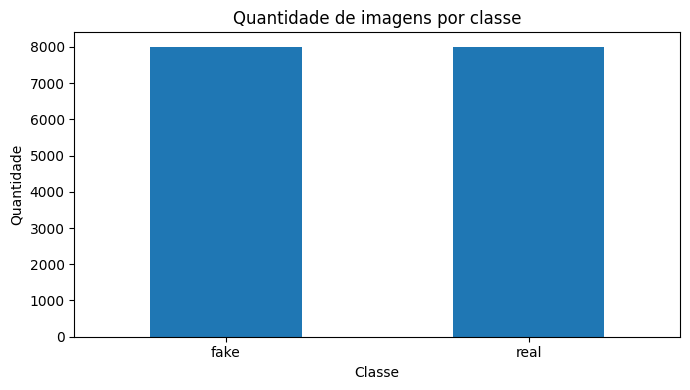

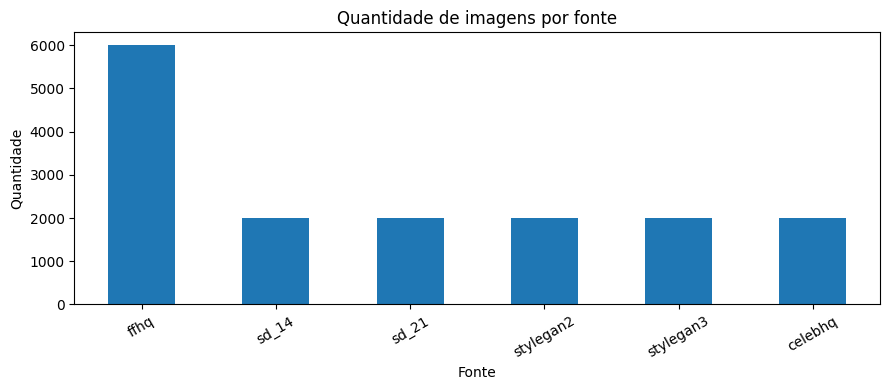

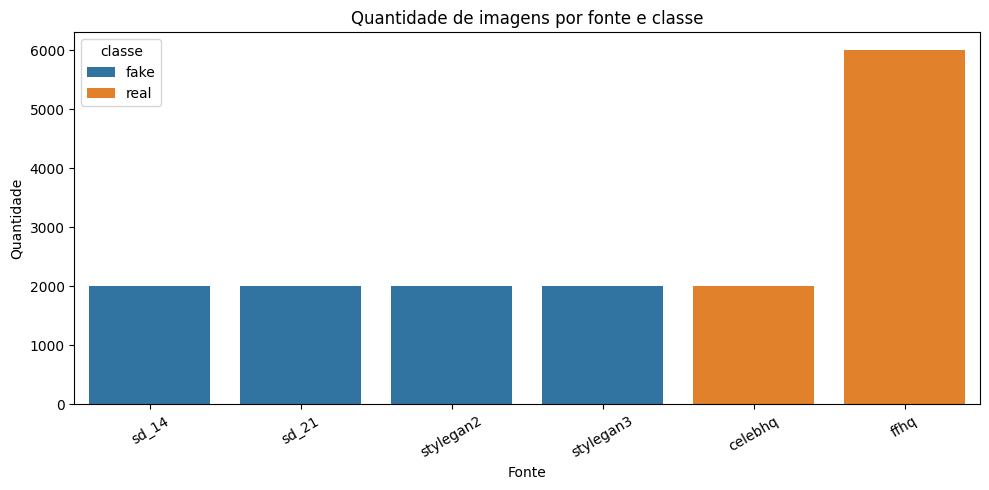

In [5]:
# ======================================================
# Distribuição por classe
# ======================================================

contagem_classe = (
    inventario["classe"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

contagem_classe.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Quantidade de imagens por classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# ======================================================
# Distribuição por fonte
# ======================================================

contagem_fonte = (
    inventario["fonte"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 4))

contagem_fonte.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Quantidade de imagens por fonte")
ax.set_xlabel("Fonte")
ax.set_ylabel("Quantidade")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# ======================================================
# Distribuição por classe e fonte
# ======================================================

contagem_classe_fonte = (
    inventario
    .groupby(["classe", "fonte"])
    .size()
    .reset_index(name="quantidade")
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=contagem_classe_fonte,
    x="fonte",
    y="quantidade",
    hue="classe",
    ax=ax
)

ax.set_title("Quantidade de imagens por fonte e classe")
ax.set_xlabel("Fonte")
ax.set_ylabel("Quantidade")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Funções auxiliares de auditoria

As métricas de qualidade são calculadas em uma representação padronizada de `256×256`, somente para comparação exploratória entre classes. Isso reduz o efeito da resolução original sobre Laplaciano, contraste, FFT e bordas.

**Importante:** essas métricas não devem virar thresholds de descarte automaticamente. Primeiro analisamos as distribuições e só depois decidimos regras.

In [6]:
TAMANHO_METRICAS = 256
MARGEM_FACE = 0.20
TAMANHO_ENTRADA_PLANEJADO = 224


def sha256_arquivo(caminho, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        while True:
            bloco = f.read(chunk_size)
            if not bloco:
                break
            h.update(bloco)
    return h.hexdigest()


def dhash_64(imagem_pil):
    img = imagem_pil.convert("L").resize((9, 8), Image.Resampling.LANCZOS)
    arr = np.asarray(img, dtype=np.int16)
    diff = arr[:, 1:] > arr[:, :-1]

    valor = 0
    for bit in diff.flatten():
        valor = (valor << 1) | int(bit)

    return int(valor)


def entropia_gray(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    prob = hist / max(hist.sum(), 1)

    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


def fft_highfreq_ratio(gray):
    arr = gray.astype(np.float32)
    arr = arr - arr.mean()

    fft = np.fft.fftshift(np.fft.fft2(arr))
    power = np.abs(fft) ** 2

    h, w = gray.shape
    yy, xx = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2

    raio = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    raio_max = np.sqrt(cy ** 2 + cx ** 2)

    mascara_alta = raio >= (0.35 * raio_max)

    energia_total = power.sum()
    if energia_total <= 0:
        return 0.0

    return float(power[mascara_alta].sum() / energia_total)


def padronizar_para_metricas(rgb, tamanho=TAMANHO_METRICAS):
    return cv2.resize(
        rgb,
        (tamanho, tamanho),
        interpolation=cv2.INTER_AREA,
    )


def calcular_metricas_imagem(rgb):
    rgb_small = padronizar_para_metricas(rgb)
    gray = cv2.cvtColor(rgb_small, cv2.COLOR_RGB2GRAY)

    blur_laplacian = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    contrast_std = float(gray.std())
    brightness_mean = float(gray.mean())
    entropy = entropia_gray(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = float((edges > 0).mean())

    fft_ratio = fft_highfreq_ratio(gray)

    mean_rgb = rgb_small.reshape(-1, 3).mean(axis=0)
    std_rgb = rgb_small.reshape(-1, 3).std(axis=0)

    return {
        "blur_laplacian_256": blur_laplacian,
        "contrast_std_256": contrast_std,
        "brightness_mean_256": brightness_mean,
        "entropy_256": entropy,
        "edge_density_256": edge_density,
        "fft_highfreq_ratio_256": fft_ratio,
        "mean_r_256": float(mean_rgb[0]),
        "mean_g_256": float(mean_rgb[1]),
        "mean_b_256": float(mean_rgb[2]),
        "std_r_256": float(std_rgb[0]),
        "std_g_256": float(std_rgb[1]),
        "std_b_256": float(std_rgb[2]),
    }

## 5. Extração completa das características

Esta é a etapa mais pesada. Ela:

- valida leitura;
- coleta resolução, modo e formato;
- calcula SHA-256 e dHash;
- calcula métricas de qualidade padronizadas;
- executa o YuNet na imagem original;
- contabiliza 0, 1 ou múltiplos rostos;
- registra tamanho e confiança do rosto único;
- estima o tamanho do crop com margem de 20%;
- calcula quanto esse crop precisaria ser ampliado/reduzido para chegar a `224×224`.

Os resultados são cacheados em `training/analysis/eda_catalogo.csv`.

In [9]:
FORCAR_RECALCULO = False
LIMITE_IMAGENS = None  # Ex.: 500 para teste rápido; None = dataset completo

CAMINHO_CACHE = CAMINHO_ANALISE / "eda_catalogo.csv"

if CAMINHO_CACHE.exists() and not FORCAR_RECALCULO:
    df = pd.read_csv(CAMINHO_CACHE)
    df["caminho"] = df["caminho"].map(Path)
    print(f"Cache carregado: {CAMINHO_CACHE}")
else:
    face_detector = FaceDetector()

    registros = []
    amostras = inventario.copy()

    if LIMITE_IMAGENS is not None:
        amostras = (
            amostras.groupby("classe", group_keys=False)
            .apply(
                lambda x: x.sample(
                    min(len(x), max(1, LIMITE_IMAGENS // inventario['classe'].nunique())),
                    random_state=SEMENTE_GLOBAL,
                )
            )
            .reset_index(drop=True)
        )

    for row in tqdm(
        amostras.itertuples(index=False),
        total=len(amostras),
        desc="Auditando imagens",
    ):
        caminho = Path(row.caminho)

        registro = {
            "caminho": str(caminho),
            "classe": row.classe,
            "rotulo": row.rotulo,
            "extensao": caminho.suffix.lower(),
            "arquivo_bytes": caminho.stat().st_size if caminho.exists() else np.nan,
            "erro_leitura": False,
            "erro_face_detector": False,
        }

        try:
            # Validação básica do arquivo
            with Image.open(caminho) as img_verify:
                img_verify.verify()

            with Image.open(caminho) as img:
                formato = img.format
                modo = img.mode
                largura, altura = img.size
                rgb = np.asarray(img.convert("RGB"))

            registro.update(
                {
                    "formato": formato,
                    "modo": modo,
                    "largura": largura,
                    "altura": altura,
                    "aspect_ratio": largura / altura if altura else np.nan,
                    "megapixels": (largura * altura) / 1_000_000,
                    "sha256": sha256_arquivo(caminho),
                }
            )

            registro["bytes_por_megapixel"] = (
                registro["arquivo_bytes"] / registro["megapixels"]
                if registro["megapixels"] > 0
                else np.nan
            )

            with Image.open(caminho) as img_hash:
                registro["dhash64"] = dhash_64(img_hash)

            registro.update(calcular_metricas_imagem(rgb))

            # YuNet usa BGR
            bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

            try:
                faces = face_detector.detect(bgr)
                n_faces = len(faces)
                registro["n_faces"] = n_faces

                if n_faces == 0:
                    registro["face_status"] = "no_face"

                elif n_faces > 1:
                    registro["face_status"] = "multiple_faces"

                else:
                    registro["face_status"] = "valid"

                    face = faces[0]
                    x, y, w, h = [float(v) for v in face[:4]]
                    score = float(face[-1])

                    registro.update(
                        {
                            "face_x": x,
                            "face_y": y,
                            "face_w": w,
                            "face_h": h,
                            "face_score": score,
                            "face_area_ratio": (w * h) / (largura * altura),
                            "face_min_dim": min(w, h),
                            "face_max_dim": max(w, h),
                        }
                    )

                    lado_crop = max(w, h) * (1 + 2 * MARGEM_FACE)
                    lado_crop = min(lado_crop, largura, altura)

                    registro["crop_side_estimado"] = lado_crop
                    registro["resize_factor_para_224"] = (
                        TAMANHO_ENTRADA_PLANEJADO / lado_crop
                        if lado_crop > 0
                        else np.nan
                    )

            except Exception as exc:
                registro["erro_face_detector"] = True
                registro["face_status"] = "detector_error"
                registro["face_detector_error_msg"] = str(exc)

        except Exception as exc:
            registro["erro_leitura"] = True
            registro["erro_leitura_msg"] = str(exc)

        registros.append(registro)

    df = pd.DataFrame(registros)
    df.to_csv(CAMINHO_CACHE, index=False)
    df["caminho"] = df["caminho"].map(Path)

    print(f"Cache salvo em: {CAMINHO_CACHE}")

print(f"Linhas no catálogo: {len(df):,}")
display(df.head())

[ WARN:0@60.659] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


Auditando imagens:   0%|          | 0/16000 [00:00<?, ?it/s]

Cache salvo em: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/analysis/eda_catalogo.csv
Linhas no catálogo: 16,000


,caminho,classe,rotulo,extensao,arquivo_bytes,erro_leitura,erro_face_detector,formato,modo,largura,altura,aspect_ratio,megapixels,sha256,bytes_por_megapixel,dhash64,blur_laplacian_256,contrast_std_256,brightness_mean_256,entropy_256,edge_density_256,fft_highfreq_ratio_256,mean_r_256,mean_g_256,mean_b_256,std_r_256,std_g_256,std_b_256,n_faces,face_status,face_x,face_y,face_w,face_h,face_score,face_area_ratio,face_min_dim,face_max_dim,crop_side_estimado,resize_factor_para_224
0,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_sd_14.jpg,fake,0,.jpg,120513,False,False,JPEG,RGB,1024,1024,1.0,1.048576,10afdba157de9e83f08a05ed4f7ccaa67c5993f1800f3070d193df8794b94948,114930.152893,10318627537420981125,137.658949,47.845279,117.671677,7.355066,0.026413,0.007113,128.184647,114.245850,107.771667,46.522390,49.637918,54.418784,1,valid,242.926926,153.466843,570.197021,802.623901,0.954729,0.436453,570.197021,802.623901,1024.0,0.21875
1,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_sd_21.jpg,fake,0,.jpg,198772,False,False,JPEG,RGB,1024,1024,1.0,1.048576,c656fd3a1abd1103942107a26b6230434cbf7c7d9d6b3479bc83322dbd407fbe,189563.751221,3634793909247423287,376.461660,49.595384,89.113312,7.428474,0.076935,0.009281,105.072937,81.631454,85.807632,62.677143,47.746954,41.232535,1,valid,240.144684,174.396332,558.352234,774.120605,0.949228,0.412209,558.352234,774.120605,1024.0,0.21875
2,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_stylegan2.jpg,fake,0,.jpg,436945,False,False,JPEG,RGB,1024,1024,1.0,1.048576,843194f5258070591cc22297b0ded4735934834f92ff273c6b422c072e66cd10,416703.224182,10274746158411247666,380.890720,71.331982,141.067291,7.440503,0.067780,0.010699,162.968323,134.148254,119.206818,68.430183,72.941182,76.754265,1,valid,253.617722,192.695389,536.708313,761.385986,0.954482,0.389712,536.708313,761.385986,1024.0,0.21875
3,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1000_stylegan3.jpg,fake,0,.jpg,1037268,False,False,JPEG,RGB,1024,1024,1.0,1.048576,cb01c72f76d0bdaaf412c8ee9ecf9f52c4e5f82f0648dfe6b3a9fdf80751ef2b,989215.850830,11377752800295773816,318.307620,49.346212,101.902542,7.582553,0.057281,0.009215,126.055054,93.887466,79.794952,54.815169,48.225593,46.808899,1,valid,127.475876,118.936424,518.153198,768.945801,0.951764,0.379974,518.153198,768.945801,1024.0,0.21875
4,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1001_sd_14.jpg,fake,0,.jpg,190614,False,False,JPEG,RGB,1024,1024,1.0,1.048576,2db3717289e4550c3a469d6b9c0d32a31f738266e68a017be9a6486d9c101289,181783.676147,2194224239105106889,155.379446,44.481646,98.985611,7.209872,0.034744,0.005468,117.195358,92.363831,85.378586,57.260059,40.072022,36.992469,1,valid,225.268188,169.355057,539.106384,777.606018,0.952303,0.399792,539.106384,777.606018,1024.0,0.21875


## 6. Integridade básica

Antes de discutir qualidade visual ou modelo, qualquer imagem corrompida deve ser identificada. Também verificamos se a quantidade observada por classe bate com a composição esperada de 8k/8k.

In [10]:
resumo_integridade = pd.DataFrame(
    {
        "total": [len(df)],
        "erros_leitura": [int(df["erro_leitura"].fillna(False).sum())],
        "erros_face_detector": [int(df["erro_face_detector"].fillna(False).sum())],
    }
)

display(resumo_integridade)
display(df["classe"].value_counts().rename("quantidade").to_frame())

esperado_classe = {"fake": 8000, "real": 8000}

for classe, esperado in esperado_classe.items():
    observado = int((df["classe"] == classe).sum())
    print(
        f"{classe:>4}: observado={observado:,} | esperado={esperado:,} | "
        f"diferença={observado - esperado:+,}"
    )

,total,erros_leitura,erros_face_detector
0,16000,0,0


,quantidade
classe,
fake,8000
real,8000


fake: observado=8,000 | esperado=8,000 | diferença=+0
real: observado=8,000 | esperado=8,000 | diferença=+0


## 7. Formato, resolução e tamanho de arquivo

Essa seção é crítica porque diferenças sistemáticas entre `real` e `fake` podem virar atalhos para a ResNet.

Exemplos de sinais de risco:
- fake majoritariamente PNG e real majoritariamente JPG;
- fake em 512×512 e real em 1024×1024;
- taxa de compressão muito diferente;
- aspect ratio específico por classe.

In [11]:
validos = df[~df["erro_leitura"].fillna(True)].copy()

print("Extensões por classe:")
display(pd.crosstab(validos["classe"], validos["extensao"], margins=True))

print("\nModos de cor por classe:")
display(pd.crosstab(validos["classe"], validos["modo"], margins=True))

print("\nFormatos PIL por classe:")
display(pd.crosstab(validos["classe"], validos["formato"], margins=True))

Extensões por classe:


extensao,.jpg,All
classe,,
fake,8000,8000
real,8000,8000
All,16000,16000



Modos de cor por classe:


modo,RGB,All
classe,,
fake,8000,8000
real,8000,8000
All,16000,16000



Formatos PIL por classe:


formato,JPEG,All
classe,,
fake,8000,8000
real,8000,8000
All,16000,16000


In [12]:
validos["resolucao"] = (
    validos["largura"].astype("Int64").astype(str)
    + "x"
    + validos["altura"].astype("Int64").astype(str)
)

top_resolucoes = (
    validos.groupby(["classe", "resolucao"])
    .size()
    .rename("quantidade")
    .reset_index()
    .sort_values(["classe", "quantidade"], ascending=[True, False])
)

display(top_resolucoes.groupby("classe").head(15))

,classe,resolucao,quantidade
0,fake,1024x1024,8000
1,real,1024x1024,8000


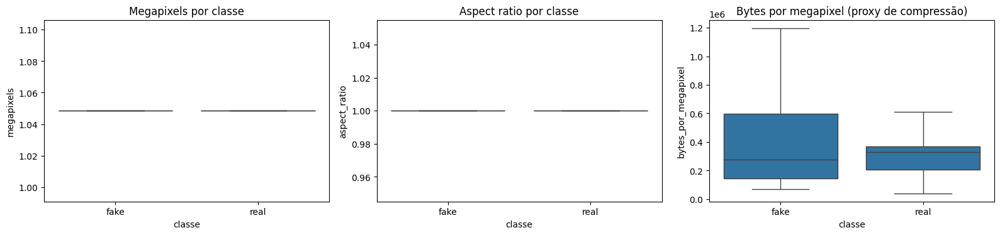

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=validos, x="classe", y="megapixels", ax=axes[0])
axes[0].set_title("Megapixels por classe")

sns.boxplot(data=validos, x="classe", y="aspect_ratio", ax=axes[1])
axes[1].set_title("Aspect ratio por classe")

sns.boxplot(data=validos, x="classe", y="bytes_por_megapixel", ax=axes[2])
axes[2].set_title("Bytes por megapixel (proxy de compressão)")

plt.tight_layout()
plt.show()

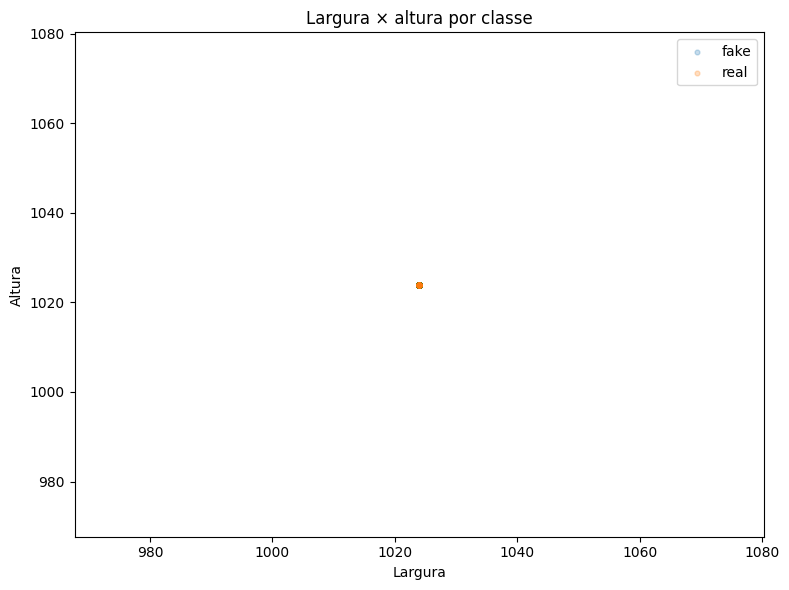

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for classe, grupo in validos.groupby("classe"):
    ax.scatter(
        grupo["largura"],
        grupo["altura"],
        alpha=0.25,
        s=12,
        label=classe,
    )

ax.set_title("Largura × altura por classe")
ax.set_xlabel("Largura")
ax.set_ylabel("Altura")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Exemplos aleatórios

Sempre inspecione visualmente algumas amostras. EDA de visão computacional não deve ser apenas tabular.

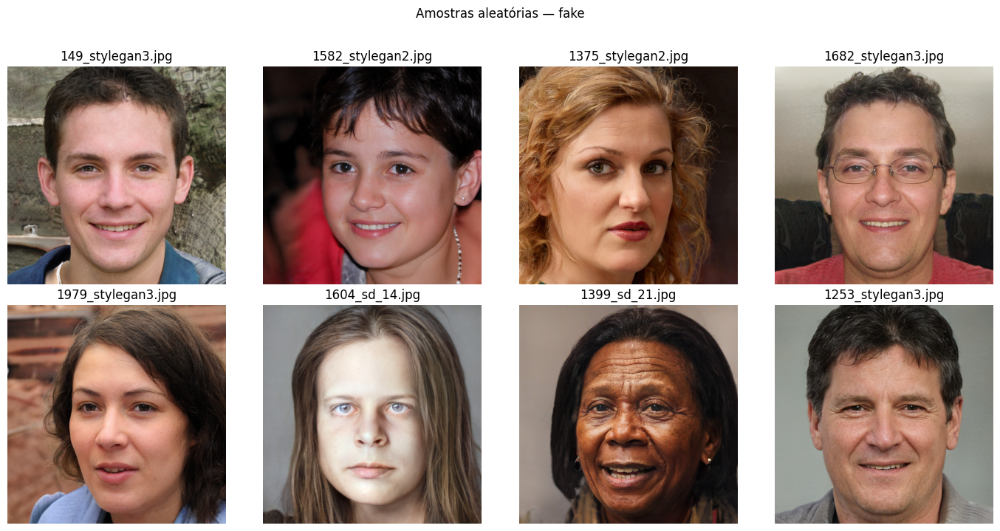

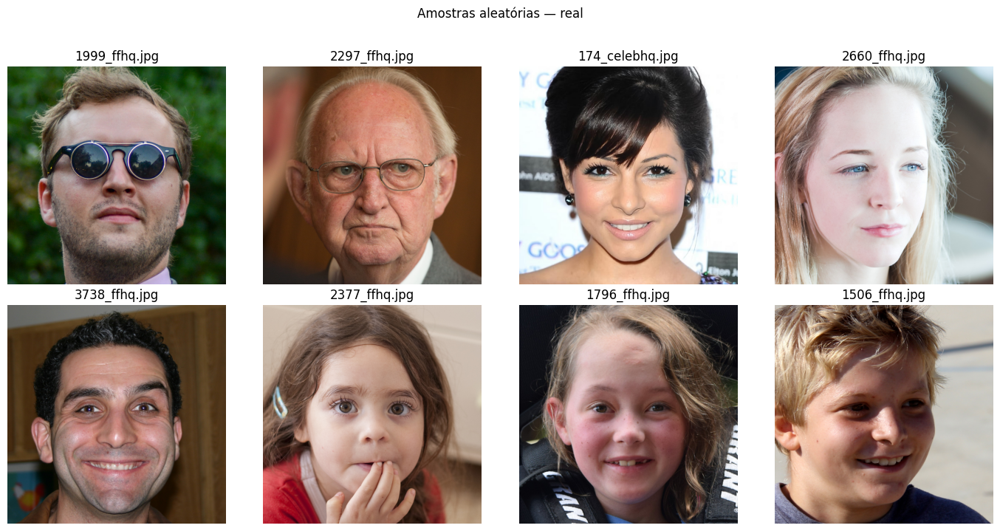

In [15]:
def mostrar_amostras(df_base, n_por_classe=8, seed=SEMENTE_GLOBAL):
    classes = sorted(df_base["classe"].dropna().unique())

    for classe in classes:
        subset = df_base[df_base["classe"] == classe]

        if len(subset) == 0:
            continue

        amostra = subset.sample(
            min(n_por_classe, len(subset)),
            random_state=seed,
        )

        cols = 4
        rows = int(np.ceil(len(amostra) / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
        axes = np.atleast_1d(axes).flatten()

        for ax, (_, row) in zip(axes, amostra.iterrows()):
            try:
                with Image.open(row["caminho"]) as img:
                    ax.imshow(img.convert("RGB"))
                ax.set_title(Path(row["caminho"]).name[:35])
            except Exception:
                ax.set_title("Erro de leitura")
            ax.axis("off")

        for ax in axes[len(amostra):]:
            ax.axis("off")

        fig.suptitle(f"Amostras aleatórias — {classe}", y=1.02)
        plt.tight_layout()
        plt.show()


mostrar_amostras(validos)

## 9. Métricas de qualidade e aparência

Não interprete uma diferença de distribuição como “fake é mais borrado” sem investigar. O objetivo principal aqui é detectar **confounders**: características globais capazes de separar as classes sem qualquer compreensão de manipulação facial.

In [16]:
metricas_qualidade = [
    "blur_laplacian_256",
    "contrast_std_256",
    "brightness_mean_256",
    "entropy_256",
    "edge_density_256",
    "fft_highfreq_ratio_256",
]

resumo_metricas = (
    validos.groupby("classe")[metricas_qualidade]
    .agg(["mean", "median", "std", "min", "max"])
)

display(resumo_metricas)

blur_laplacian_256                                                  \
                     mean      median         std        min          max   
classe                                                                      
fake           300.413860  274.850565  176.195389  15.961972  1723.137594   
real           602.115988  495.006384  412.041943  44.134131  5847.179757   

       contrast_std_256                                               \
                   mean     median        std        min         max   
classe                                                                 
fake          53.001966  52.986479  11.796659  16.331772  102.899333   
real          58.823688  58.502846  11.289176  21.463194   98.794108   

       brightness_mean_256                                                \
                      mean      median        std        min         max   
classe                                                                     
fake            111.377240  111.191559  23.031001  30.326782  198.446701   
real            114.228616  113.568771  28.774096  31.238968  230.056473   

       entropy_256                                         edge_density_256  \
              mean    median       std       min       max             mean   
classe                                                                        
fake      7.299343  7.367214  0.338004  4.515851  7.921843         0.049190   
real      7.382037  7.450028  0.332546  4.664068  7.971649         0.071634   

                                               fft_highfreq_ratio_256  \
          median       std       min       max                   mean   
classe                                                                  
fake    0.047005  0.021980  0.000763  0.213638               0.008341   
real    0.067421  0.026932  0.010345  0.210922               0.012936   

                                                
          median       std       min       max  
classe                                          
fake    0.007490  0.004256  0.001105  0.048850  
real    0.011074  0.007735  0.001615  0.146796

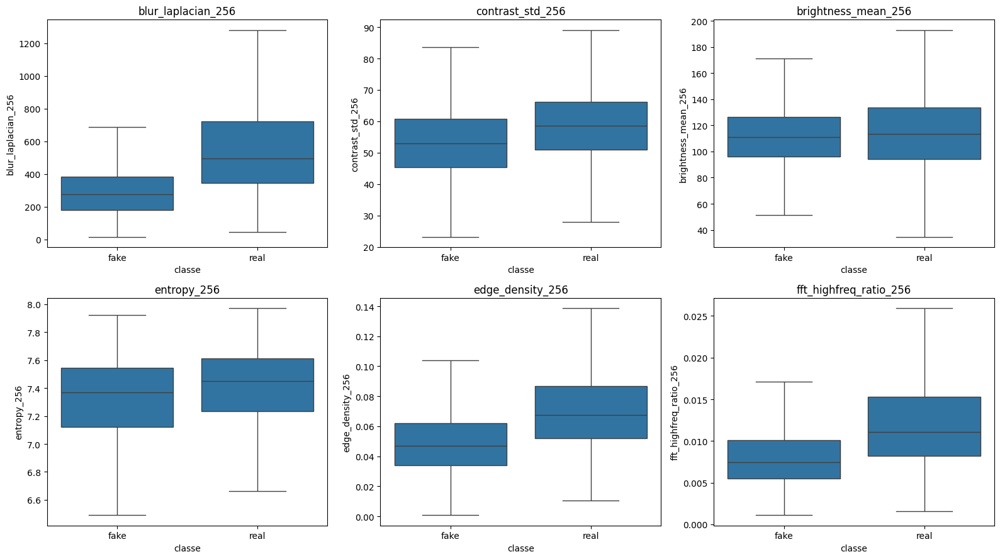

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metrica in zip(axes, metricas_qualidade):
    sns.boxplot(
        data=validos,
        x="classe",
        y=metrica,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(metrica)

plt.tight_layout()
plt.show()

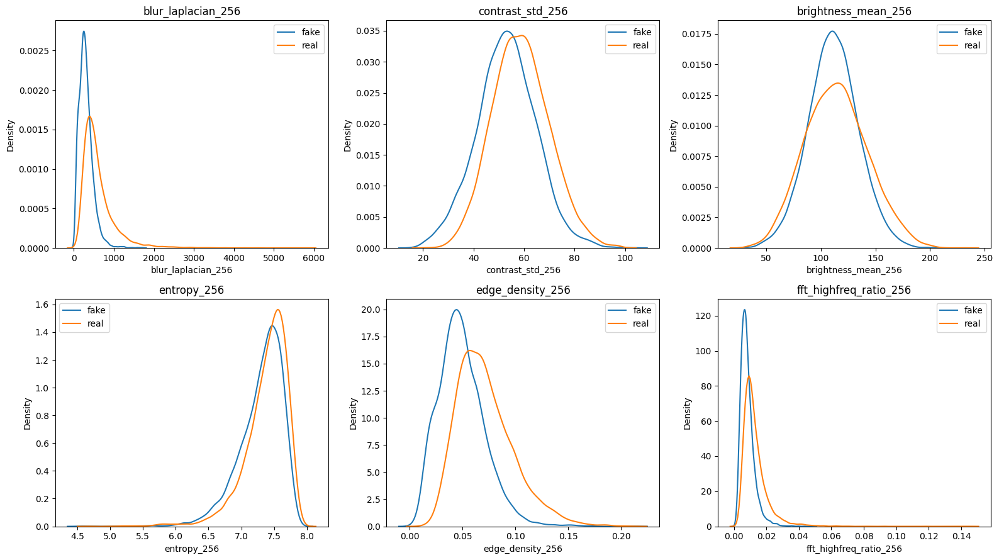

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metrica in zip(axes, metricas_qualidade):
    for classe, grupo in validos.groupby("classe"):
        sns.kdeplot(
            data=grupo,
            x=metrica,
            ax=ax,
            label=classe,
            fill=False,
        )

    ax.set_title(metrica)
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Estatísticas de cor

Diferenças grandes de balanço de cor entre classes são outro possível atalho de dataset.

In [19]:
metricas_cor = [
    "mean_r_256",
    "mean_g_256",
    "mean_b_256",
    "std_r_256",
    "std_g_256",
    "std_b_256",
]

display(
    validos.groupby("classe")[metricas_cor]
    .agg(["mean", "median", "std"])
)

mean_r_256                         mean_g_256                         \
              mean      median        std        mean      median        std   
classe                                                                         
fake    128.160547  128.303787  24.596386  106.032879  105.843681  23.285623   
real    132.688319  132.323624  30.832664  108.278645  107.696487  29.187690   

       mean_b_256                        std_r_256                        \
             mean     median        std       mean     median        std   
classe                                                                     
fake    94.875569  93.779831  24.485205  59.030086  59.320087  13.139305   
real    96.437108  94.802139  30.059717  65.170559  65.296157  12.737352   

        std_g_256                        std_b_256                        
             mean     median        std       mean     median        std  
classe                                                                    
fake    52.186577  51.829587  12.167424  51.005755  50.100112  13.373961  
real    58.538644  58.069137  11.764570  57.627826  56.842034  13.222763

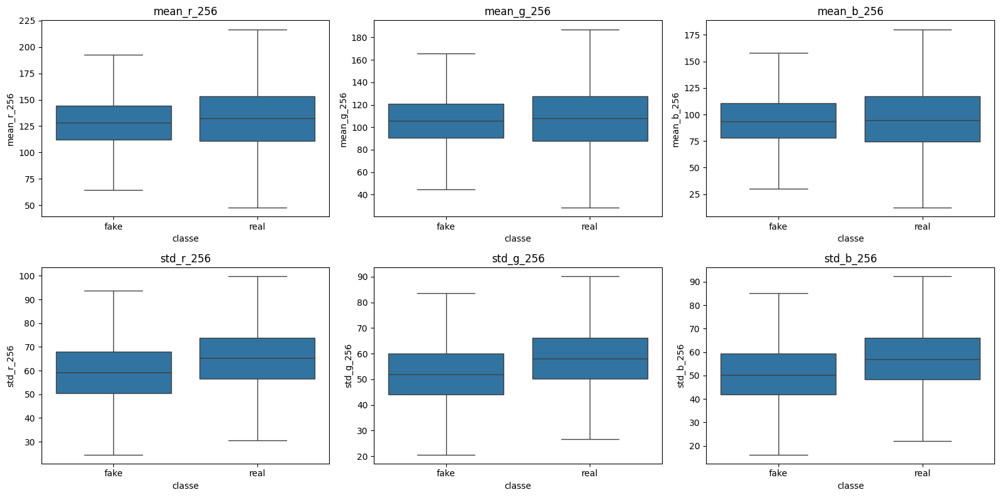

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, metrica in zip(axes, metricas_cor):
    sns.boxplot(
        data=validos,
        x="classe",
        y=metrica,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(metrica)

plt.tight_layout()
plt.show()

## 11. Auditoria facial com YuNet

Pelo requisito do sistema, uma imagem é válida quando contém **exatamente um rosto humano detectável**.

- `0 faces`: rejeitar / investigar;
- `1 face`: válida;
- `2+ faces`: rejeitar / investigar;
- erro do detector: investigar separadamente.

In [22]:
print("Status facial geral:")
display(df["face_status"].value_counts(dropna=False).rename("quantidade").to_frame())

print("\nStatus facial por classe:")
display(pd.crosstab(df["classe"], df["face_status"], margins=True))

Status facial geral:


,quantidade
face_status,
valid,15960
multiple_faces,29
no_face,11



Status facial por classe:


face_status,multiple_faces,no_face,valid,All
classe,,,,
fake,2,0,7998,8000
real,27,11,7962,8000
All,29,11,15960,16000


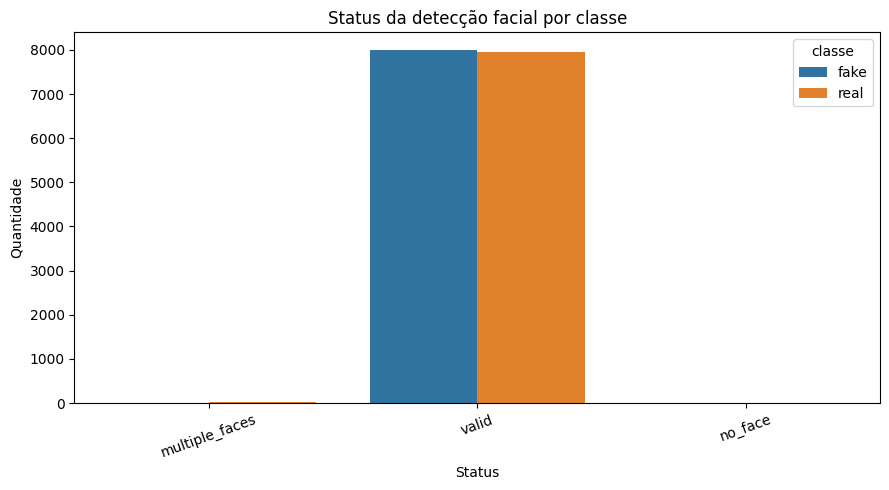

In [23]:
face_counts = (
    df.groupby(["classe", "face_status"])
    .size()
    .rename("quantidade")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=face_counts,
    x="face_status",
    y="quantidade",
    hue="classe",
    ax=ax,
)
ax.set_title("Status da detecção facial por classe")
ax.set_xlabel("Status")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 11.1 Características das faces válidas

Aqui analisamos:
- confiança do YuNet;
- área ocupada pelo rosto;
- menor dimensão da face;
- tamanho estimado do crop com margem de 20%;
- fator necessário para transformar o crop em 224×224.

Interpretação de `resize_factor_para_224`:
- `< 1`: o crop será reduzido;
- `≈ 1`: resolução próxima de 224;
- `> 1`: o crop precisará ser ampliado;
- `> 2`: alerta forte — o modelo receberá um rosto significativamente interpolado.

In [24]:
faces_validas = df[df["face_status"] == "valid"].copy()

colunas_face = [
    "face_score",
    "face_area_ratio",
    "face_min_dim",
    "crop_side_estimado",
    "resize_factor_para_224",
]

display(
    faces_validas.groupby("classe")[colunas_face]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

face_score                                                              \
            count      mean       std       min        1%        5%       10%   
classe                                                                          
fake       7998.0  0.949163  0.007214  0.910302  0.928474  0.935993  0.939573   
real       7962.0  0.940869  0.008939  0.900310  0.914237  0.924226  0.929218   

                                                                              \
             25%       50%       75%       90%       95%       99%       max   
classe                                                                         
fake    0.944874  0.950076  0.954450  0.957447  0.959061  0.961761  0.966991   
real    0.935776  0.941974  0.947244  0.951225  0.953269  0.956494  0.962592   

       face_area_ratio                                                    \
                 count      mean       std       min        1%        5%   
classe                                                                     
fake            7998.0  0.410334  0.039637  0.273441  0.321008  0.346929   
real            7962.0  0.408940  0.048704  0.238788  0.306502  0.334561   

                                                                              \
             10%       25%       50%       75%       90%       95%       99%   
classe                                                                         
fake    0.361349  0.384214  0.409054  0.434807  0.459951  0.478087  0.511963   
real    0.349537  0.375565  0.405926  0.439059  0.473157  0.493228  0.535808   

                 face_min_dim                                                 \
             max        count        mean        std         min          1%   
classe                                                                         
fake    0.630577       7998.0  562.561756  30.410118  452.244965  491.118585   
real    0.625322       7962.0  563.879916  35.983517  407.721008  479.024913   

                                                                    \
                5%         10%         25%         50%         75%   
classe                                                               
fake    511.611671  522.867383  543.233688  563.523560  581.508652   
real    506.797630  520.552295  541.016312  562.591431  585.899872   

                                                       crop_side_estimado  \
               90%         95%         99%         max              count   
classe                                                                      
fake    599.872913  611.705908  639.299924  705.745483             7998.0   
real    609.360681  625.554721  656.366940  709.936890             7962.0   

                                                                    \
               mean        std         min          1%          5%   
classe                                                               
fake    1016.618659  19.219168  854.059729  934.880579  971.944668   
real    1009.803108  29.982584  763.174573  892.480528  940.481565   

                                                                         \
               10%          25%     50%     75%     90%     95%     99%   
classe                                                                    
fake    993.164580  1024.000000  1024.0  1024.0  1024.0  1024.0  1024.0   
real    965.547871  1012.983228  1024.0  1024.0  1024.0  1024.0  1024.0   

               resize_factor_para_224                                        \
           max                  count      mean       std      min       1%   
classe                                                                        
fake    1024.0                 7998.0  0.220422  0.004451  0.21875  0.21875   
real    1024.0                 7962.0  0.222038  0.007180  0.21875  0.21875   

                                                                          \
             5%      10%      25%      50%       75%       90%       95%   
class

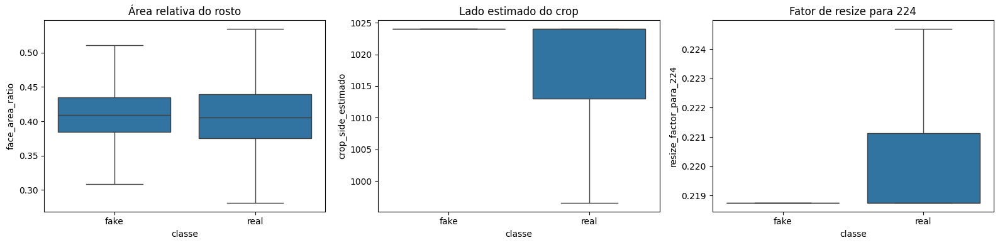

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(
    data=faces_validas,
    x="classe",
    y="face_area_ratio",
    ax=axes[0],
    showfliers=False,
)
axes[0].set_title("Área relativa do rosto")

sns.boxplot(
    data=faces_validas,
    x="classe",
    y="crop_side_estimado",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Lado estimado do crop")

sns.boxplot(
    data=faces_validas,
    x="classe",
    y="resize_factor_para_224",
    ax=axes[2],
    showfliers=False,
)
axes[2].set_title("Fator de resize para 224")

plt.tight_layout()
plt.show()

In [26]:
def percentual(condicao):
    return 100 * float(condicao.mean()) if len(condicao) else np.nan


resumo_resize = pd.DataFrame(
    [
        {
            "classe": classe,
            "n_faces_validas": len(grupo),
            "% precisa ampliar (>1x)": percentual(grupo["resize_factor_para_224"] > 1),
            "% amplia >1.5x": percentual(grupo["resize_factor_para_224"] > 1.5),
            "% amplia >2x": percentual(grupo["resize_factor_para_224"] > 2),
        }
        for classe, grupo in faces_validas.groupby("classe")
    ]
)

display(resumo_resize)

,classe,n_faces_validas,% precisa ampliar (>1x),% amplia >1.5x,% amplia >2x
0,fake,7998,0.0,0.0,0.0
1,real,7962,0.0,0.0,0.0


## 12. Visualização das detecções do YuNet

As bounding boxes devem ser inspecionadas visualmente. Um detector pode retornar `1 face` e ainda assim estar errado ou mal centralizado.

[ WARN:0@672.467] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


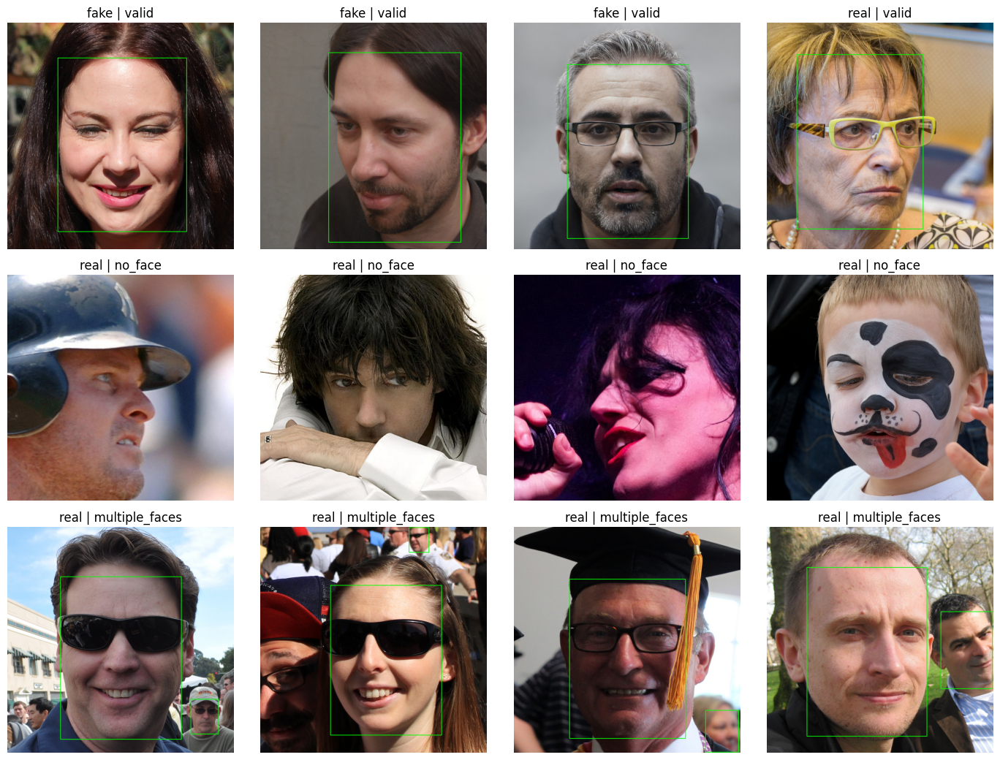

In [27]:
face_detector_viz = FaceDetector()


def desenhar_faces(caminho):
    imagem = cv2.imread(str(caminho))

    if imagem is None:
        return None, "read_error"

    faces = face_detector_viz.detect(imagem)

    canvas = imagem.copy()

    for face in faces:
        x, y, w, h = [int(v) for v in face[:4]]
        cv2.rectangle(
            canvas,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2,
        )

    canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

    if len(faces) == 0:
        status = "no_face"
    elif len(faces) == 1:
        status = "valid"
    else:
        status = "multiple_faces"

    return canvas, status


amostra_viz = pd.concat(
    [
        df[df["face_status"] == status].sample(
            min(4, len(df[df["face_status"] == status])),
            random_state=SEMENTE_GLOBAL,
        )
        for status in ["valid", "no_face", "multiple_faces"]
        if len(df[df["face_status"] == status]) > 0
    ],
    ignore_index=True,
)

if len(amostra_viz):
    cols = 4
    rows = int(np.ceil(len(amostra_viz) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, row) in zip(axes, amostra_viz.iterrows()):
        canvas, status = desenhar_faces(row["caminho"])

        if canvas is not None:
            ax.imshow(canvas)

        ax.set_title(f"{row['classe']} | {status}")
        ax.axis("off")

    for ax in axes[len(amostra_viz):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 13. Duplicatas exatas

Duplicatas podem inflar artificialmente as métricas se cópias da mesma imagem forem separadas entre treino, validação e teste.

Duplicatas entre `real` e `fake` são especialmente suspeitas e devem ser investigadas.

In [29]:
grupos_duplicados = (
    df.dropna(subset=["sha256"])
    .groupby("sha256")
    .filter(lambda g: len(g) > 1)
    .sort_values("sha256")
)

print(f"Imagens pertencentes a grupos duplicados: {len(grupos_duplicados):,}")

if len(grupos_duplicados):
    resumo_dup = (
        grupos_duplicados.groupby("sha256")
        .agg(
            quantidade=("caminho", "size"),
            classes=("classe", lambda x: sorted(set(x))),
            caminhos=("caminho", lambda x: list(map(str, x))),
        )
        .reset_index()
    )

    resumo_dup["cross_class"] = resumo_dup["classes"].map(len) > 1

    print(f"Grupos duplicados: {len(resumo_dup):,}")
    print(f"Grupos duplicados cross-class: {int(resumo_dup['cross_class'].sum()):,}")

    display(resumo_dup.head(20))
else:
    resumo_dup = pd.DataFrame()
    print("Nenhuma duplicata exata encontrada.")

Imagens pertencentes a grupos duplicados: 0
Nenhuma duplicata exata encontrada.


## 14. Candidatos a quase-duplicatas por dHash

Esta etapa usa distância de Hamming em dHash 64-bit.

Ela **não prova** que duas imagens são duplicadas. O objetivo é gerar candidatos para inspeção visual.

Para evitar comparação O(N²), usamos buckets de 16 bits. Com limiar `<=4`, pares próximos tendem a compartilhar pelo menos um bloco idêntico.

In [30]:
LIMIAR_DHASH = 4
MAX_BUCKET = 200


def hamming64(a, b):
    return int((int(a) ^ int(b)).bit_count())


hash_df = df.dropna(subset=["dhash64"]).reset_index(drop=True).copy()
hash_df["dhash64"] = hash_df["dhash64"].astype("uint64")

buckets = defaultdict(list)

for idx, valor in enumerate(hash_df["dhash64"]):
    valor = int(valor)

    for chunk_idx in range(4):
        chunk = (valor >> (16 * chunk_idx)) & 0xFFFF
        buckets[(chunk_idx, chunk)].append(idx)


pares_candidatos = set()
buckets_ignorados = 0

for indices in buckets.values():
    if len(indices) > MAX_BUCKET:
        buckets_ignorados += 1
        continue

    for i, j in combinations(indices, 2):
        if i > j:
            i, j = j, i
        pares_candidatos.add((i, j))


near_duplicates = []

for i, j in tqdm(pares_candidatos, desc="Comparando candidatos dHash"):
    h1 = int(hash_df.loc[i, "dhash64"])
    h2 = int(hash_df.loc[j, "dhash64"])

    distancia = hamming64(h1, h2)

    if distancia <= LIMIAR_DHASH:
        near_duplicates.append(
            {
                "idx_a": i,
                "idx_b": j,
                "distancia_dhash": distancia,
                "classe_a": hash_df.loc[i, "classe"],
                "classe_b": hash_df.loc[j, "classe"],
                "caminho_a": str(hash_df.loc[i, "caminho"]),
                "caminho_b": str(hash_df.loc[j, "caminho"]),
                "cross_class": hash_df.loc[i, "classe"] != hash_df.loc[j, "classe"],
            }
        )

df_near = pd.DataFrame(near_duplicates)

print(f"Buckets ignorados por excesso de itens: {buckets_ignorados}")
print(f"Pares candidatos avaliados: {len(pares_candidatos):,}")
print(f"Pares com dHash <= {LIMIAR_DHASH}: {len(df_near):,}")

if len(df_near):
    print(f"Quase-duplicatas cross-class: {int(df_near['cross_class'].sum()):,}")
    display(df_near.sort_values(["distancia_dhash", "cross_class"], ascending=[True, False]).head(30))

    df_near.to_csv(
        CAMINHO_ANALISE / "eda_near_duplicates.csv",
        index=False,
    )

Comparando candidatos dHash:   0%|          | 0/454120 [00:00<?, ?it/s]

Buckets ignorados por excesso de itens: 2
Pares candidatos avaliados: 454,120
Pares com dHash <= 4: 1,056
Quase-duplicatas cross-class: 406


,idx_a,idx_b,distancia_dhash,classe_a,classe_b,caminho_a,caminho_b,cross_class
82,2342,15478,0,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1528_stylegan2.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/766_celebhq.jpg,True
79,4014,14681,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1904_stylegan2.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/5650_ffhq.jpg,True
90,4258,9950,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/195_stylegan2.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/187_celebhq.jpg,True
156,6139,15623,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/581_stylegan3.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/830_ffhq.jpg,True
242,3711,8452,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1836_stylegan3.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/1204_celebhq.jpg,True
442,6727,15623,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/713_stylegan3.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/830_ffhq.jpg,True
513,468,13300,1,fake,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/1106_sd_14.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/451_ffhq.jpg,True
58,8992,9888,1,real,real,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/1448_celebhq.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/real/1851_celebhq.jpg,False
74,1107,6973,1,fake,fake,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/124_stylegan3.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/76_sd_21.jpg,False
98,5673,6517,1,fake,fake,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/477_sd_21.jpg,/home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset/fake/667_sd_21.jpg,False


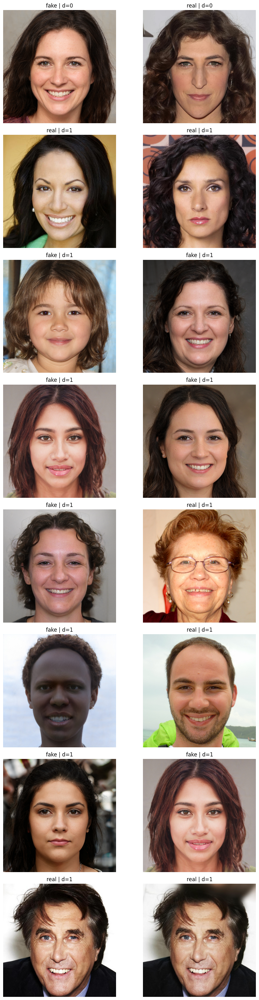

In [31]:
def mostrar_pares_near_duplicates(df_pares, n=8):
    if df_pares is None or len(df_pares) == 0:
        print("Nenhum par disponível.")
        return

    amostra = df_pares.sort_values("distancia_dhash").head(n)

    fig, axes = plt.subplots(len(amostra), 2, figsize=(10, 4 * len(amostra)))

    if len(amostra) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(amostra.iterrows()):
        for col_idx, lado in enumerate(["a", "b"]):
            caminho = Path(row[f"caminho_{lado}"])

            with Image.open(caminho) as img:
                axes[row_idx, col_idx].imshow(img.convert("RGB"))

            axes[row_idx, col_idx].set_title(
                f"{row[f'classe_{lado}']} | d={row['distancia_dhash']}"
            )
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


if len(df_near):
    mostrar_pares_near_duplicates(df_near, n=min(8, len(df_near)))

## 15. Outliers visuais

Os extremos devem ser vistos manualmente. Um valor de blur baixo pode significar imagem realmente borrada, mas também pode ser estética suave, baixa resolução ou erro de leitura.

In [32]:
def mostrar_extremos(
    df_base,
    metrica,
    n=8,
    maiores=False,
    titulo=None,
):
    subset = df_base.dropna(subset=[metrica]).sort_values(
        metrica,
        ascending=not maiores,
    ).head(n)

    if len(subset) == 0:
        return

    cols = 4
    rows = int(np.ceil(len(subset) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.8 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, row) in zip(axes, subset.iterrows()):
        try:
            with Image.open(row["caminho"]) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(
                f"{row['classe']}\n{metrica}={row[metrica]:.3f}"
            )
        except Exception:
            ax.set_title("Erro")

        ax.axis("off")

    for ax in axes[len(subset):]:
        ax.axis("off")

    fig.suptitle(titulo or metrica, y=1.02)
    plt.tight_layout()
    plt.show()

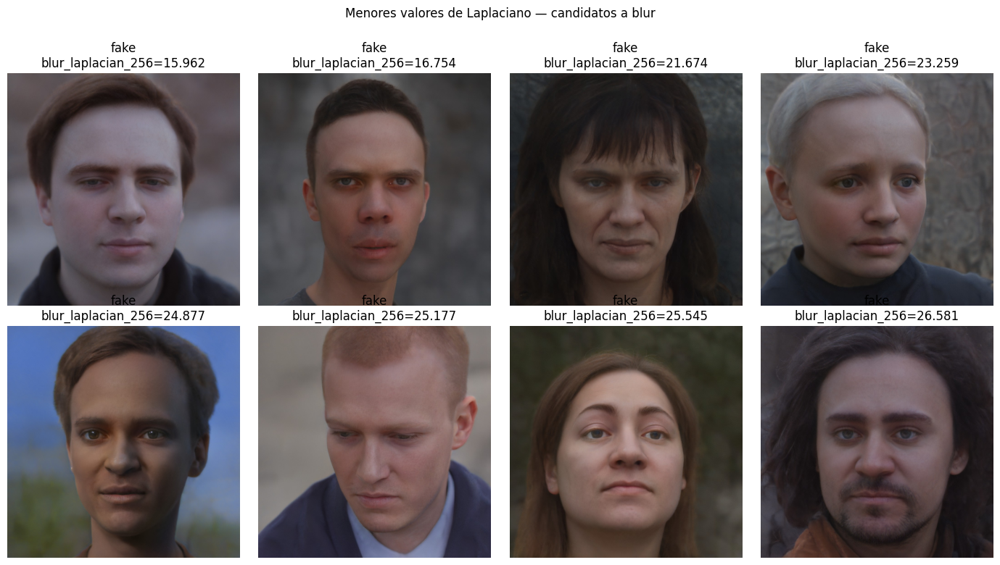

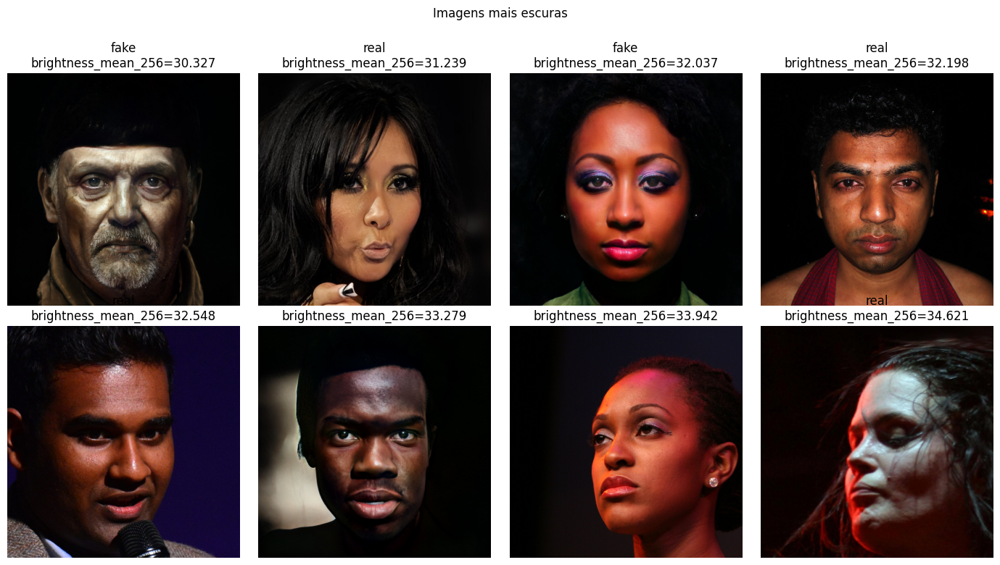

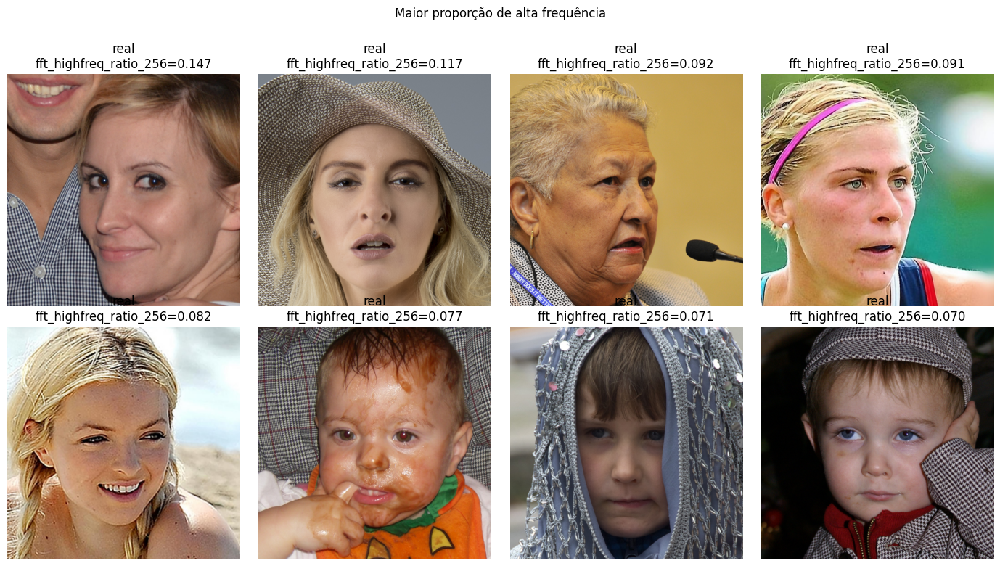

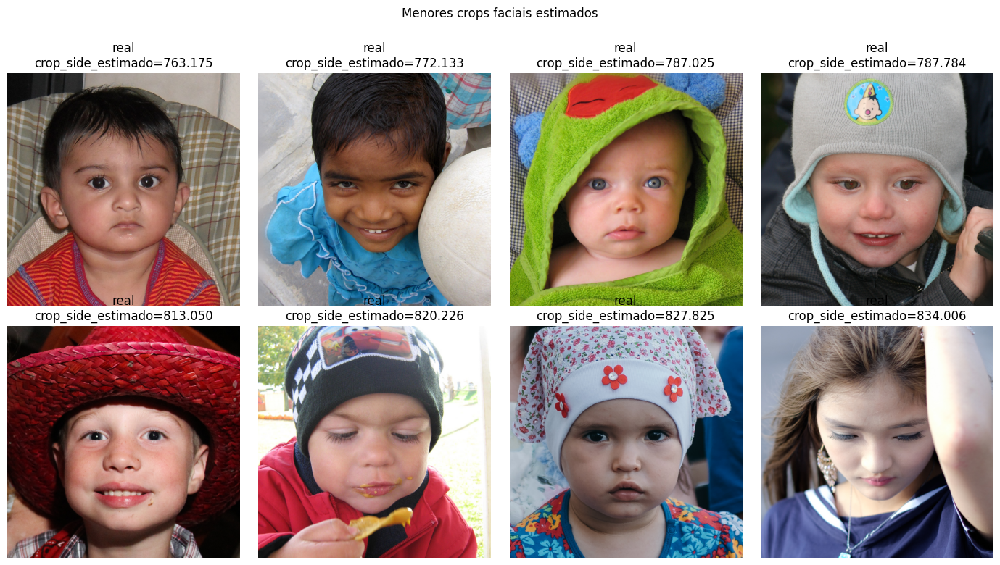

In [33]:
mostrar_extremos(
    validos,
    "blur_laplacian_256",
    n=8,
    maiores=False,
    titulo="Menores valores de Laplaciano — candidatos a blur",
)

mostrar_extremos(
    validos,
    "brightness_mean_256",
    n=8,
    maiores=False,
    titulo="Imagens mais escuras",
)

mostrar_extremos(
    validos,
    "fft_highfreq_ratio_256",
    n=8,
    maiores=True,
    titulo="Maior proporção de alta frequência",
)

mostrar_extremos(
    faces_validas,
    "crop_side_estimado",
    n=8,
    maiores=False,
    titulo="Menores crops faciais estimados",
)

## 16. Correlações e possíveis atalhos

A matriz abaixo serve para localizar dependências entre resolução, tamanho de arquivo e métricas visuais. Não interprete correlação como causalidade.

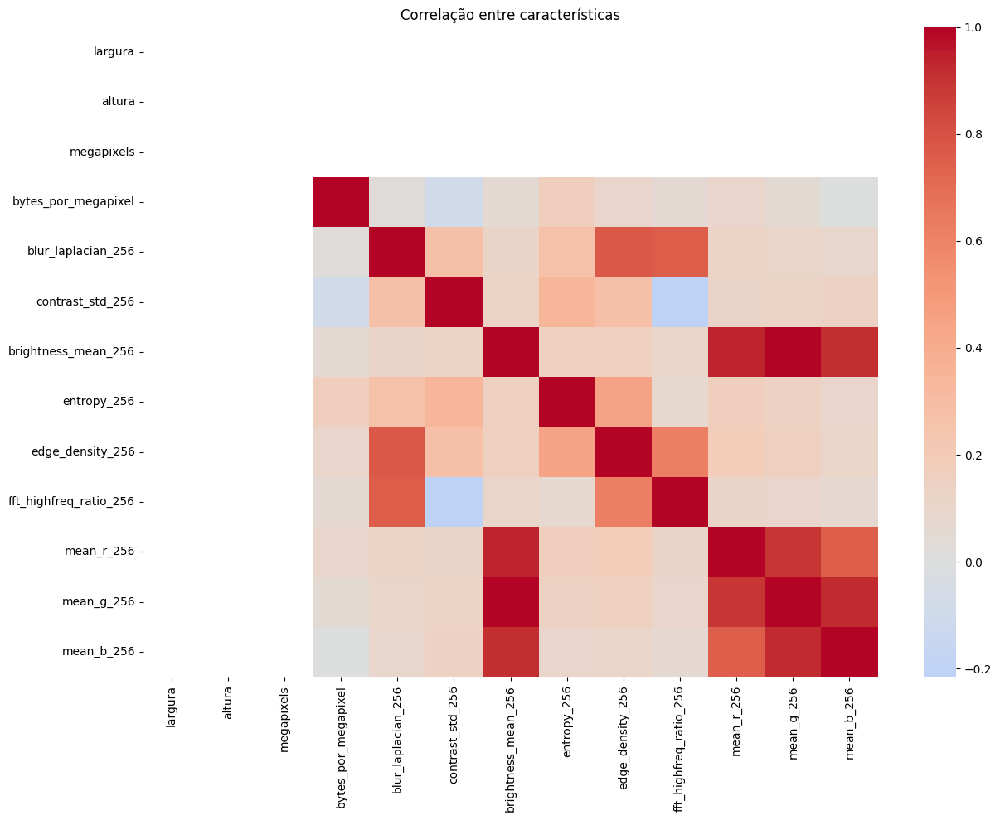

In [34]:
colunas_numericas = [
    "largura",
    "altura",
    "megapixels",
    "bytes_por_megapixel",
    "blur_laplacian_256",
    "contrast_std_256",
    "brightness_mean_256",
    "entropy_256",
    "edge_density_256",
    "fft_highfreq_ratio_256",
    "mean_r_256",
    "mean_g_256",
    "mean_b_256",
]

corr = validos[colunas_numericas].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Correlação entre características")
plt.tight_layout()
plt.show()

## 17. Resumo técnico / decision gates

Esta célula consolida alguns alertas que devem ser resolvidos antes de treinar.

Eles não substituem análise humana, mas ajudam a impedir que o pipeline avance ignorando problemas básicos.

In [35]:
alertas = []

# 1. Quantidade por classe
for classe, esperado in {"fake": 8000, "real": 8000}.items():
    observado = int((df["classe"] == classe).sum())
    if observado != esperado:
        alertas.append(
            f"[CONTAGEM] {classe}: esperado {esperado}, observado {observado}."
        )

# 2. Leitura
n_erros = int(df["erro_leitura"].fillna(False).sum())
if n_erros:
    alertas.append(f"[INTEGRIDADE] {n_erros} arquivos com erro de leitura.")

# 3. Faces
n_no_face = int((df["face_status"] == "no_face").sum())
n_multi = int((df["face_status"] == "multiple_faces").sum())
n_detector = int((df["face_status"] == "detector_error").sum())

if n_no_face:
    alertas.append(f"[FACE] {n_no_face} imagens sem rosto detectado.")
if n_multi:
    alertas.append(f"[FACE] {n_multi} imagens com múltiplos rostos.")
if n_detector:
    alertas.append(f"[FACE] {n_detector} erros do detector facial.")

# 4. Upscaling
if len(faces_validas):
    pct_up2 = 100 * float(
        (faces_validas["resize_factor_para_224"] > 2).mean()
    )

    if pct_up2 > 1:
        alertas.append(
            f"[RESOLUÇÃO FACIAL] {pct_up2:.2f}% das faces exigiriam ampliação >2x para 224."
        )

# 5. Duplicatas exatas
if len(grupos_duplicados):
    n_grupos_cross = 0

    for _, grupo in grupos_duplicados.groupby("sha256"):
        if grupo["classe"].nunique() > 1:
            n_grupos_cross += 1

    alertas.append(
        f"[DUPLICATAS] Existem duplicatas exatas; {n_grupos_cross} grupos são cross-class."
    )

# 6. Near duplicates
if "df_near" in globals() and len(df_near):
    cross_near = int(df_near["cross_class"].sum())
    alertas.append(
        f"[QUASE-DUPLICATAS] {len(df_near)} pares candidatos; {cross_near} cross-class."
    )

print("=" * 70)
print("RESUMO DE ALERTAS")
print("=" * 70)

if not alertas:
    print("Nenhum alerta automático crítico encontrado.")
else:
    for alerta in alertas:
        print("-", alerta)

RESUMO DE ALERTAS
- [FACE] 11 imagens sem rosto detectado.
- [FACE] 29 imagens com múltiplos rostos.
- [QUASE-DUPLICATAS] 1056 pares candidatos; 406 cross-class.


## 18. Recomendações metodológicas antes do split

### 1. Não faça split aleatório apenas por imagem se houver relação de origem
Se diferentes imagens vierem do mesmo vídeo, identidade, seed, prompt, lote de geração ou imagem ancestral, essas unidades precisam permanecer no mesmo split.

### 2. Preserve proveniência
Hoje a estrutura `fake/real` não permite saber, por arquivo, se o fake veio de StyleGAN2, StyleGAN3, SD1.4 ou SD2.1, nem se o real veio de FFHQ ou CelebA-HQ.

Idealmente, mantenha um manifesto como:

```text
caminho, classe, fonte, source_id
...
fake/xxx.png, fake, stylegan2, seed_123
real/yyy.jpg, real, ffhq, identity_456
```

### 3. O risco de confusão classe × fonte é alto
Como os reais vêm de FFHQ/CelebA-HQ e os fakes de geradores específicos, um teste IID aleatório mede principalmente desempenho dentro dessa mistura de fontes. Ele não demonstra necessariamente generalização para novos geradores ou novos datasets reais.

Um protocolo mais forte inclui ao menos um teste **cross-source / out-of-distribution**, por exemplo:
- treinar sem um gerador e testá-lo isoladamente;
- testar em um dataset real não usado no treino;
- separar geradores/fonte em experimentos de generalização.

### 4. YuNet antes do resize
A ordem recomendada continua:

```text
imagem original
→ YuNet
→ exatamente 1 rosto
→ crop quadrado + margem
→ resize para 224×224
→ augmentation de treino
→ normalização ImageNet
→ ResNet34
```

### 5. Não defina thresholds de blur/contraste antes de observar as distribuições
Especialmente em deepfake, filtros agressivos podem remover sinais reais da tarefa e alterar a distribuição entre classes.

## 19. Exportação do catálogo final

O CSV abaixo pode ser reutilizado para definir exclusões, construir o dataset facial processado e documentar a metodologia.

In [36]:
CAMINHO_CATALOGO_FINAL = CAMINHO_ANALISE / "eda_catalogo.csv"

df_export = df.copy()
df_export["caminho"] = df_export["caminho"].map(str)
df_export.to_csv(CAMINHO_CATALOGO_FINAL, index=False)

print(f"Catálogo salvo em: {CAMINHO_CATALOGO_FINAL}")
print(f"Linhas: {len(df_export):,}")

Catálogo salvo em: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/analysis/eda_catalogo.csv
Linhas: 16,000
